# Project 01 — E-Commerce Sales Analysis
**Pluto Academy Data Analytics Internship**

**Dataset:** Olist Brazilian E-Commerce Dataset (Kaggle)
**Tools:** Python (Pandas, Matplotlib, Seaborn)

**Problem statement:** As a Data Analyst at an e-commerce company, analyse 12 months of sales
data to identify trends, compare categories and regions, build a management dashboard, and
report actionable business insights.

**Note on data:** This notebook uses `orders`, `order_items`, `products`, `reviews`, and
`customers` files from the Olist dataset. If running in Google Colab, upload the CSV files
from the Kaggle download into the same folder as this notebook (or mount Google Drive) before
running the cells below.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA = "data/"   # change this path if your CSVs are stored elsewhere (e.g. Colab upload folder)


## 1. Load the data

In [2]:
orders = pd.read_csv(DATA + "olist_orders_dataset.csv")
items = pd.read_csv(DATA + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA + "olist_products_dataset.csv")
reviews = pd.read_csv(DATA + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(DATA + "olist_customers_dataset.csv")
cat_translation = pd.read_csv(DATA + "product_category_name_translation.csv")

print("orders:", orders.shape)
print("order_items:", items.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)


orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)
customers: (99441, 5)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 2. Data Cleaning

Cleaning decisions made in this section (documented as required):

1. **Missing values** — checked with `.isnull().sum()` on every table before touching anything.
2. **Data types** — all timestamp columns in `orders` are converted from text to `datetime`.
3. **Order status filter** — only orders with status `delivered` are kept for revenue analysis.
   Cancelled / unavailable orders never generated real revenue for the business, so including
   them would inflate and distort the sales numbers.
4. **Duplicates** — checked and removed with `.drop_duplicates()` on every table.
5. **Missing product category** — filled with `'unknown'` rather than dropped, so we don't lose
   the revenue those rows represent.
6. **Category translation** — Portuguese category names are merged with the English translation
   file so charts are readable.
7. **Merge** — `order_items` + `orders` (delivered only) + `products` + `customers` are merged
   into one flat analysis table, one row per item sold.


In [4]:
# Missing values check
print("Missing values in orders:\n", orders.isnull().sum()[orders.isnull().sum() > 0])
print("\nMissing values in products:\n", products.isnull().sum()[products.isnull().sum() > 0])


Missing values in orders:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Missing values in products:
 product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [5]:
# Fix data types - convert timestamp columns to datetime
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

orders.dtypes[date_cols]


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [6]:
# Keep only delivered orders (real, completed revenue)
before = len(orders)
orders_delivered = orders[orders["order_status"] == "delivered"].copy()
print(f"Kept {len(orders_delivered)} delivered orders out of {before} total")


Kept 96478 delivered orders out of 99441 total


In [7]:
# Duplicate check + removal
for name, d in [("orders", orders_delivered), ("items", items), ("products", products)]:
    print(name, "duplicate rows:", d.duplicated().sum())

items = items.drop_duplicates()
products = products.drop_duplicates()
orders_delivered = orders_delivered.drop_duplicates()


orders duplicate rows: 0


items duplicate rows: 0
products duplicate rows: 0


In [8]:
# Fill missing product category, translate to English
products["product_category_name"] = products["product_category_name"].fillna("unknown")
products = products.merge(cat_translation, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna(
    products["product_category_name"]
)


In [9]:
# Merge into one analysis table
df = items.merge(orders_delivered, on="order_id", how="inner")
df = df.merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
df = df.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

# revenue = item price + freight, matching Olist's own order-value definition
df["revenue"] = df["price"] + df["freight_value"]
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

print("Final analysis table shape:", df.shape)
df.head()


Final analysis table shape: (110197, 18)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name_english,customer_state,revenue,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,cool_stuff,RJ,72.19,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,pet_shop,SP,259.83,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,furniture_decor,MG,216.87,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,perfumery,SP,25.78,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,garden_tools,SP,218.04,2017-02


## 3. Sales Analysis — 5 Questions

### Q1. Which product category has the highest revenue?

In [10]:
cat_revenue = df.groupby("product_category_name_english")["revenue"].sum().sort_values(ascending=False)
cat_revenue.head(10)


product_category_name_english
health_beauty            1412089.53
watches_gifts            1264333.12
bed_bath_table           1225209.26
sports_leisure           1118256.91
computers_accessories    1032723.77
furniture_decor           880329.92
housewares                758392.25
cool_stuff                691680.89
auto                      669454.75
garden_tools              567145.68
Name: revenue, dtype: float64

### Q2. Which month had peak sales?

In [11]:
monthly_sales = df.groupby("order_month")["revenue"].sum().sort_index()
print("Peak month:", monthly_sales.idxmax(), "-> R$", round(monthly_sales.max(), 2))
monthly_sales


Peak month: 2017-11 -> R$ 1153364.2


order_month
2016-09        143.46
2016-10      46490.66
2016-12         19.62
2017-01     127482.37
2017-02     271239.32
2017-03     414330.95
2017-04     390812.40
2017-05     566851.40
2017-06     490050.37
2017-07     566299.08
2017-08     645832.36
2017-09     701077.49
2017-10     751117.01
2017-11    1153364.20
2017-12     843078.29
2018-01    1077887.46
2018-02     966168.41
2018-03    1120598.24
2018-04    1132878.93
2018-05    1128774.52
2018-06    1011978.29
2018-07    1027807.28
2018-08     985491.64
Name: revenue, dtype: float64

### Q3. Which region (state) performs best?

In [12]:
state_sales = df.groupby("customer_state")["revenue"].sum().sort_values(ascending=False)
print("Top state:", state_sales.idxmax())
state_sales.head(10)


Top state: SP


customer_state
SP    5769703.15
RJ    2055401.57
MG    1818891.67
RS     861472.79
PR     781708.80
SC     595127.78
BA     591137.81
DF     346123.35
GO     334212.35
ES     317657.93
Name: revenue, dtype: float64

### Q4. What is the average order value (AOV) trend?

In [13]:
order_value = df.groupby("order_id")["revenue"].sum().reset_index()
order_value = order_value.merge(orders_delivered[["order_id", "order_purchase_timestamp"]], on="order_id")
order_value["order_month"] = order_value["order_purchase_timestamp"].dt.to_period("M").astype(str)

aov_trend = order_value.groupby("order_month")["revenue"].mean().sort_index()
print("Overall average order value: R$", round(order_value["revenue"].mean(), 2))
aov_trend


Overall average order value: R$ 159.83


order_month
2016-09    143.460000
2016-10    175.436453
2016-12     19.620000
2017-01    169.976493
2017-02    164.089123
2017-03    162.738001
2017-04    169.697091
2017-05    159.856571
2017-06    156.315907
2017-07    146.254928
2017-08    154.026320
2017-09    168.934335
2017-10    167.734929
2017-11    158.233530
2017-12    152.925502
2018-01    152.480897
2018-02    147.394113
2018-03    160.016884
2018-04    166.648857
2018-05    167.250633
2018-06    165.925281
2018-07    166.878922
2018-08    155.171097
Name: revenue, dtype: float64

### Q5. What is the customer review score distribution?

In [14]:
review_dist = reviews["review_score"].value_counts().sort_index()
print("Average review score:", round(reviews["review_score"].mean(), 2))
review_dist


Average review score: 4.09


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

## 4. Visualisations — 6 Charts

**Chart 1 — Bar chart: Revenue by category**

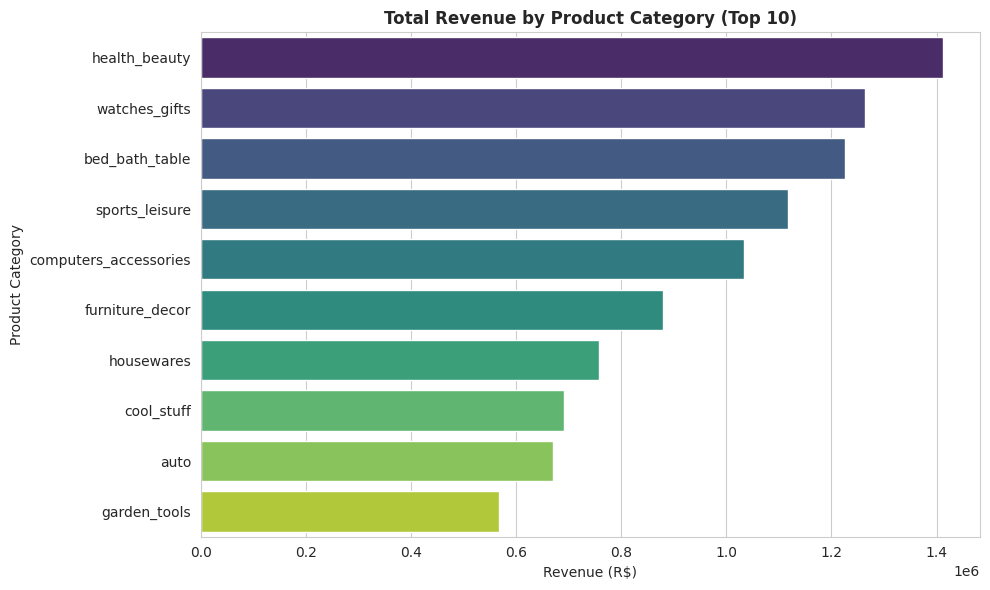

In [15]:
plt.figure(figsize=(10, 6))
top10 = cat_revenue.head(10)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="viridis", legend=False)
plt.title("Total Revenue by Product Category (Top 10)", fontweight="bold")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


**Chart 2 — Line chart: Monthly sales trend**

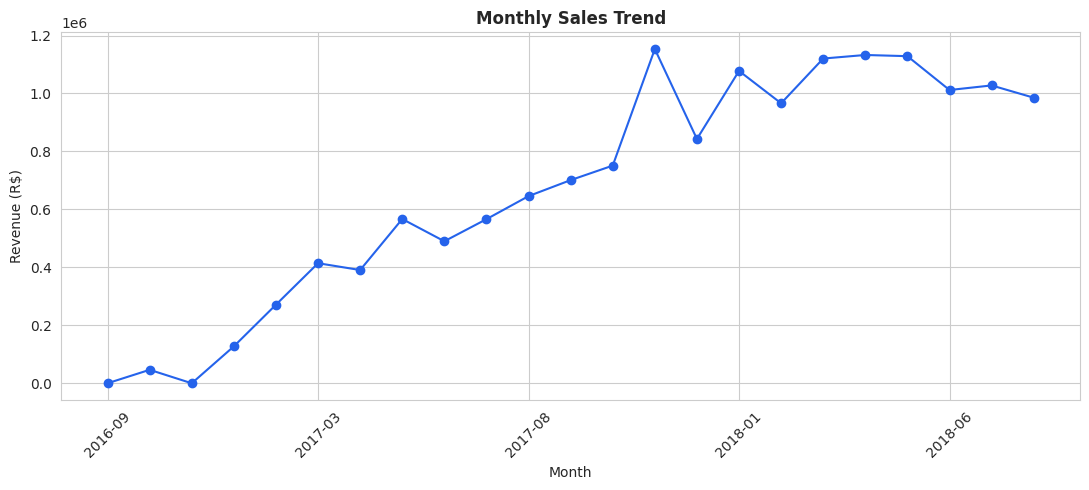

In [16]:
plt.figure(figsize=(11, 5))
monthly_sales.plot(kind="line", marker="o", color="#2563eb")
plt.title("Monthly Sales Trend", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Chart 3 — Bar chart: Regional (state) sales**

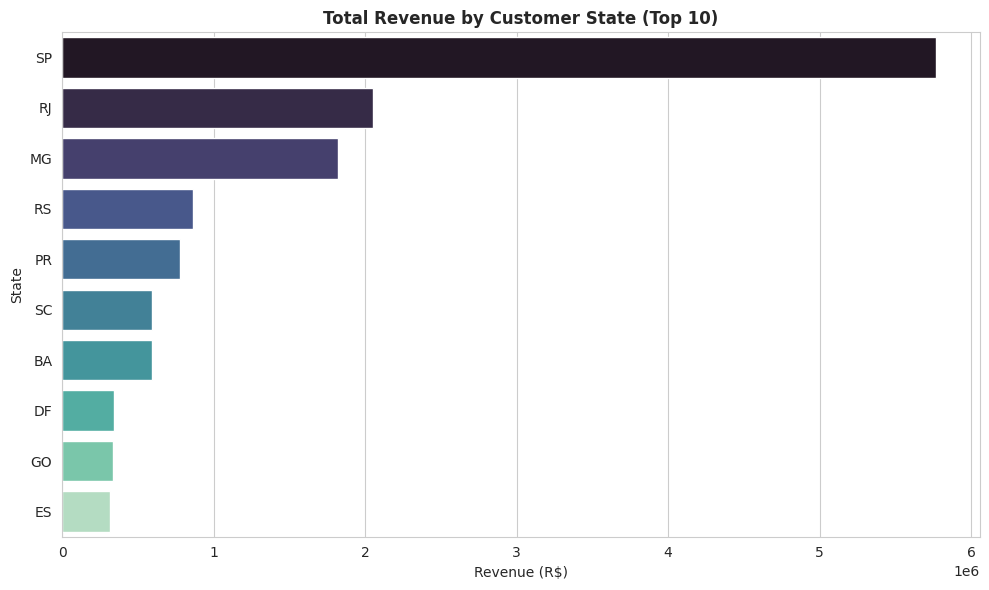

In [17]:
plt.figure(figsize=(10, 6))
top_states = state_sales.head(10)
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette="mako", legend=False)
plt.title("Total Revenue by Customer State (Top 10)", fontweight="bold")
plt.xlabel("Revenue (R$)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


**Chart 4 — Histogram: Order value distribution**

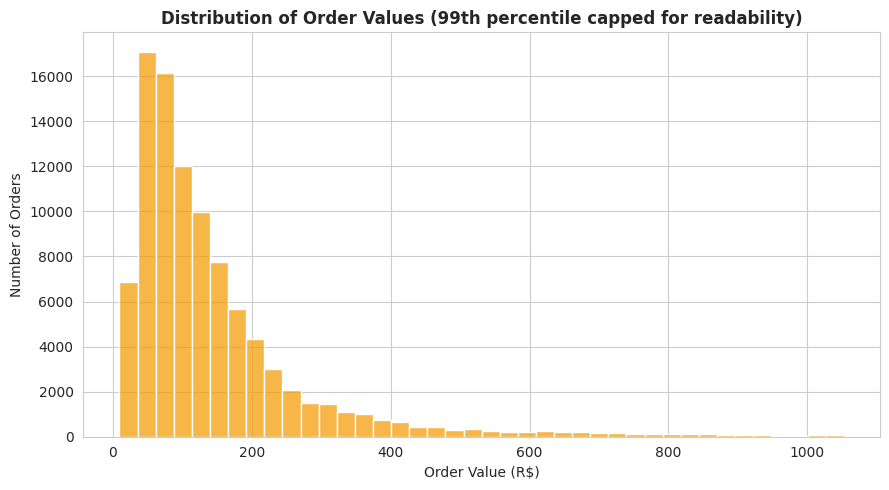

In [18]:
plt.figure(figsize=(9, 5))
capped = order_value[order_value["revenue"] < order_value["revenue"].quantile(0.99)]
sns.histplot(capped["revenue"], bins=40, color="#f59e0b")
plt.title("Distribution of Order Values (99th percentile capped for readability)", fontweight="bold")
plt.xlabel("Order Value (R$)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


**Chart 5 — Pie chart: Review score distribution**

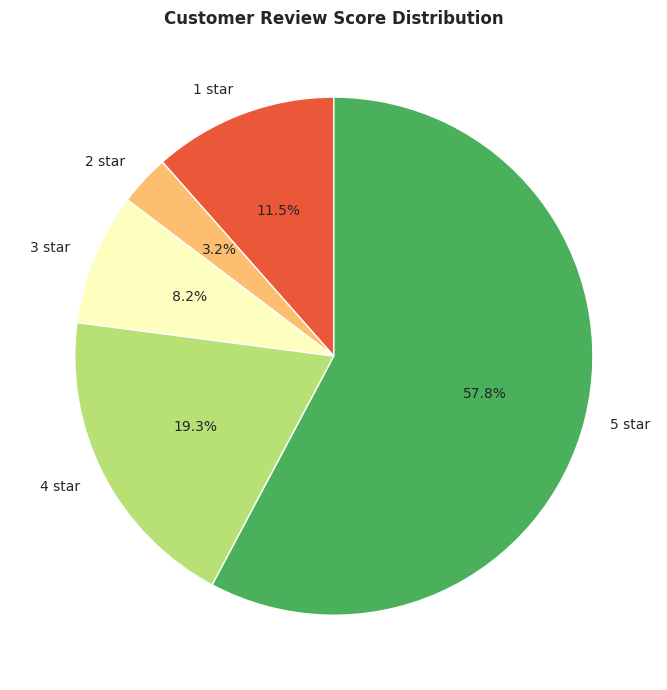

In [19]:
plt.figure(figsize=(7, 7))
colors = sns.color_palette("RdYlGn", len(review_dist))
plt.pie(review_dist.values, labels=[f"{i} star" for i in review_dist.index],
        autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Customer Review Score Distribution", fontweight="bold")
plt.tight_layout()
plt.show()


**Chart 6 — Heatmap: Category vs Month**

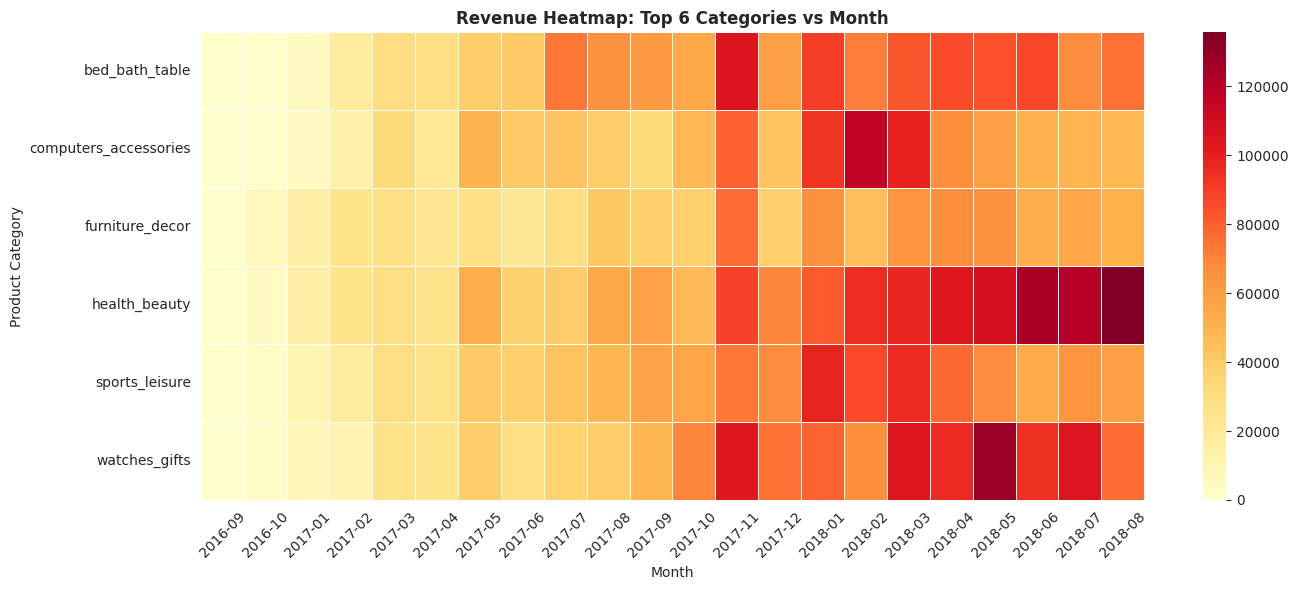

In [20]:
top6_cats = cat_revenue.head(6).index
heat_data = df[df["product_category_name_english"].isin(top6_cats)]
heat_pivot = heat_data.pivot_table(index="product_category_name_english",
                                    columns="order_month", values="revenue",
                                    aggfunc="sum", fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heat_pivot, cmap="YlOrRd", linewidths=0.5)
plt.title("Revenue Heatmap: Top 6 Categories vs Month", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Management Dashboard

A 1-page KPI summary a manager can read at a glance.

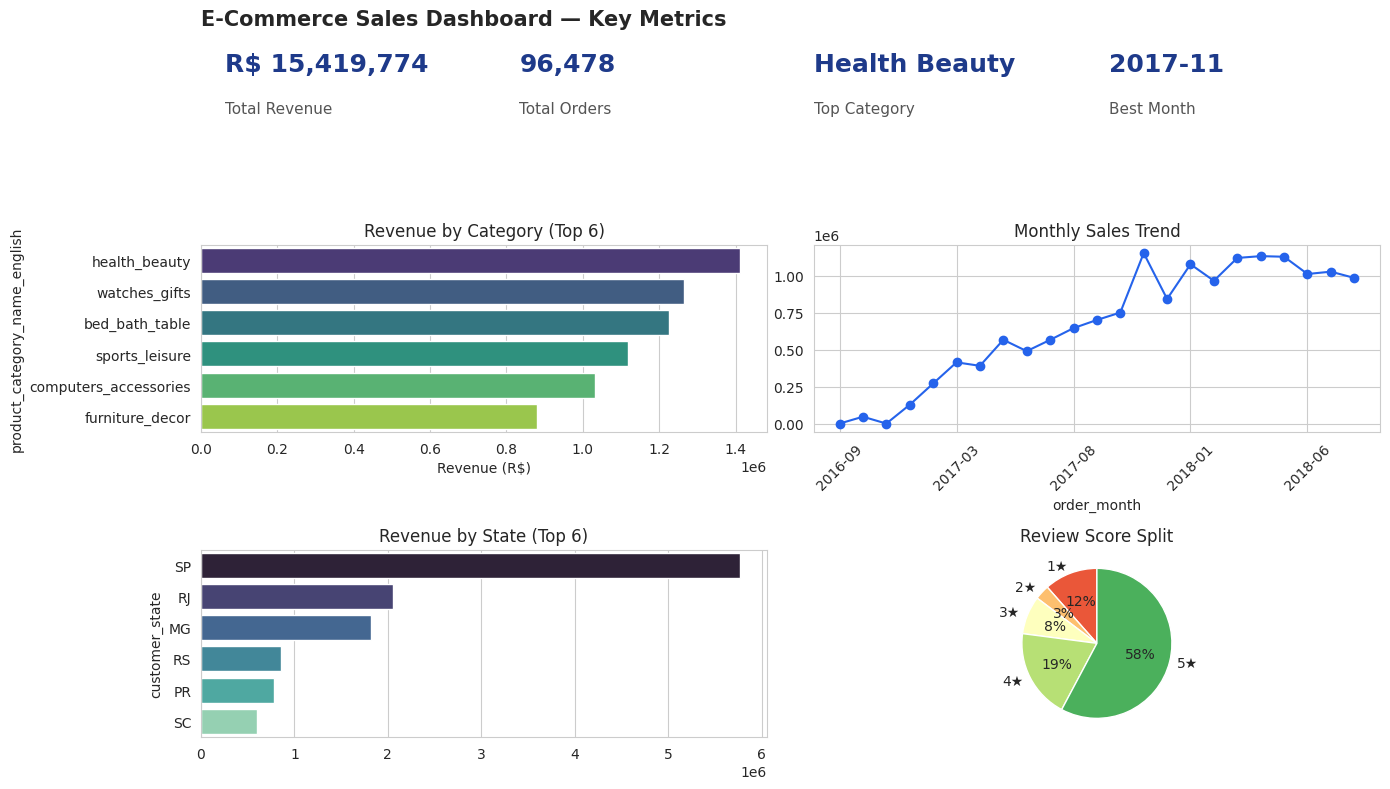

In [21]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
top_category = cat_revenue.index[0]
best_month = monthly_sales.idxmax()

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(3, 2, height_ratios=[0.6, 1.2, 1.2])

kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis("off")
kpis = [
    ("Total Revenue", f"R$ {total_revenue:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Top Category", top_category.replace("_", " ").title()),
    ("Best Month", best_month),
]
for i, (label, value) in enumerate(kpis):
    x = 0.02 + i * 0.25
    kpi_ax.text(x, 0.6, value, fontsize=18, fontweight="bold", color="#1e3a8a")
    kpi_ax.text(x, 0.15, label, fontsize=11, color="#555")
kpi_ax.set_title("E-Commerce Sales Dashboard — Key Metrics", fontsize=15, fontweight="bold", loc="left")

ax1 = fig.add_subplot(gs[1, 0])
sns.barplot(x=top10.values[:6], y=top10.index[:6], hue=top10.index[:6], palette="viridis", legend=False, ax=ax1)
ax1.set_title("Revenue by Category (Top 6)")
ax1.set_xlabel("Revenue (R$)")

ax2 = fig.add_subplot(gs[1, 1])
monthly_sales.plot(kind="line", marker="o", color="#2563eb", ax=ax2)
ax2.set_title("Monthly Sales Trend")
ax2.tick_params(axis="x", rotation=45)

ax3 = fig.add_subplot(gs[2, 0])
sns.barplot(x=top_states.values[:6], y=top_states.index[:6], hue=top_states.index[:6], palette="mako", legend=False, ax=ax3)
ax3.set_title("Revenue by State (Top 6)")

ax4 = fig.add_subplot(gs[2, 1])
ax4.pie(review_dist.values, labels=[f"{i}\u2605" for i in review_dist.index],
        autopct="%1.0f%%", colors=colors, startangle=90)
ax4.set_title("Review Score Split")

plt.tight_layout()
plt.show()


## 6. Business Insights Report

*(Written after reviewing all charts and KPIs above — fill in your own words based on what you observed. Suggested numbers are pulled from the analysis; rewrite the sentences in your own voice before submitting.)*

**1. [Category] drives the largest share of revenue.**
Insight referencing Chart 1 — the top category and how far ahead it is of the next one.
Recommendation: e.g. prioritise inventory and marketing spend on this category.

**2. Sales peaked in [Month] and show a clear seasonal pattern.**
Insight referencing Chart 2 — describe the trend shape (growth, dip, spike).
Recommendation: e.g. plan staffing and stock ahead of the next expected peak.

**3. [State] is the strongest-performing region.**
Insight referencing Chart 3 — top state vs the rest.
Recommendation: e.g. explore why weaker states underperform — logistics, marketing reach, etc.

**4. Average order value shows [trend].**
Insight referencing Chart 4 and the AOV trend — is it rising, falling, or flat? What does the order-value distribution shape tell you?
Recommendation: e.g. bundle offers to lift AOV, or address any decline.

**5. Customer satisfaction is [mostly positive / mixed], based on review scores.**
Insight referencing Chart 5 — % of 5-star vs 1-star reviews.
Recommendation: e.g. investigate causes of low scores (delivery delays, product quality) to protect repeat purchase rate.

---
**Most surprising finding (3–5 lines):**
*Write your own short note here on what stood out most while doing this analysis.*
